# Compare Gaia parallax distances with Bailer-Jones distances

This notebook cross-matches the Gaia DR3 radial-velocity sample with the Bailer-Jones et al. geometric and photogeometric distance catalog. It applies the Gaia DR3 parallax zero-point correction and compares both the corrected and uncorrected inverse-parallax distances with the tabulated photogeometric distances.

The workflow is designed for the AstroFlow Dask deployment and Gaia parquet mirrors. It expects `DASK_DATA_PATH_GAIA_DR3_SSD` to contain `GDR3_GAIA_SOURCE` and `DASK_DATA_PATH_GAIA_EDR3_SSD` to contain `GEDR3DIST`. The latter is the Gaia EDR3 distance catalog from [Bailer-Jones et al. (2021)](https://ui.adsabs.harvard.edu/abs/2021AJ....161..147B/abstract).

Distances inferred as `1 / parallax` are expressed in kiloparsecs because Gaia parallaxes are in milliarcseconds. They are used here as diagnostics, not as recommended distance estimators for low-signal-to-noise or non-positive parallaxes.

In [1]:
from pathlib import Path
import os

In [2]:
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec



In [3]:
# Connect to the distributed scheduler. The default is AstroFlow-specific.
import dask.dataframe as dd
from dask.distributed import Client
scheduler_address = os.environ.get(
    'DASK_SCHEDULER_ADDRESS',
    'tcp://simple-scheduler.dask-operator.svc.cluster.local:8786',
)
c = Client(scheduler_address)
print(c)


<Client: 'tcp://172.19.205.29:8786' processes=10 threads=50, memory=700.00 GiB>


/opt/conda/lib/python3.12/site-packages/distributed/client.py:1590: VersionMismatchWarning: Mismatched versions found

+---------+--------+-----------+---------+
| Package | Client | Scheduler | Workers |
+---------+--------+-----------+---------+
| numpy   | 2.0.2  | 2.2.6     | 2.2.6   |
| toolz   | 1.0.0  | 0.12.0    | 0.12.0  |
+---------+--------+-----------+---------+
  warnings.warn(version_module.VersionMismatchWarning(msg[0]["warning"]))


In [4]:
import easy2dhist
c.upload_file("easy2dhist.py")

{'tcp://172.16.162.213:37033': {'status': 'OK'},
 'tcp://172.16.162.222:39731': {'status': 'OK'},
 'tcp://172.18.196.153:37531': {'status': 'OK'},
 'tcp://172.18.196.162:34633': {'status': 'OK'},
 'tcp://172.18.196.170:46833': {'status': 'OK'},
 'tcp://172.19.205.24:41659': {'status': 'OK'},
 'tcp://172.19.205.51:34765': {'status': 'OK'},
 'tcp://172.19.205.59:45267': {'status': 'OK'},
 'tcp://172.19.205.61:39125': {'status': 'OK'},
 'tcp://172.19.205.9:44295': {'status': 'OK'}}

In [5]:
# Install the zero-point package in the notebook and on every Dask worker.
!pip install gaiadr3-zeropoint

c.run(lambda: __import__('subprocess').run(['pip', 'install', 'gaiadr3-zeropoint'], check=True))


{'tcp://172.16.162.213:37033': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.16.162.222:39731': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.18.196.153:37531': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.18.196.162:34633': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.18.196.170:46833': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.19.205.24:41659': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.19.205.51:34765': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.19.205.59:45267': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.19.205.61:39125': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.19.205.9:44

## Load and select the distributed catalogs

The Gaia table is restricted to sources with radial velocities, while the distance table is restricted to rows with a finite median photogeometric distance. Only Gaia columns needed for the zero-point correction and subsequent diagnostics are retained before the cross-match. Persisting these filtered tables avoids repeating the same scans in later distributed operations.

In [6]:
_t1 = time.time()

gaia_source = dd.read_parquet(Path(os.environ['DASK_DATA_PATH_GAIA_DR3_SSD']).joinpath("GDR3_GAIA_SOURCE"),  engine="pyarrow")
dist_table = dd.read_parquet(Path(os.environ['DASK_DATA_PATH_GAIA_EDR3_SSD']).joinpath("GEDR3DIST"),  engine="pyarrow")

# Tell Dask the data is pre-sorted on source_id
#gaia_source  = gaia_source.set_index("source_id",  sorted=True)
#dist_table = dist_table.set_index("source_id", sorted=True) 

print('Time elapsed: ',time.time()-_t1)

# r_med_geo	r_lo_geo	r_hi_geo	r_med_photogeo	r_lo_photogeo	r_hi_photogeo	flag

Time elapsed:  0.4350879192352295


In [7]:

# select all sources with reported radial velocity
gaia_source = gaia_source[
    gaia_source["radial_velocity"].notnull()
].persist()


In [8]:



# filter on valid tabulated distances
dist_table = dist_table[dist_table["r_med_photogeo"].notnull()].persist()

In [9]:

astrometric_features = [
    'source_id',
    'ra',
    'dec',
# for distance determination
    'parallax','parallax_error','parallax_over_error',
# for RVS sample testing
    'radial_velocity','radial_velocity_error',
# for computing zeropoint
    'phot_g_mean_mag',
    'nu_eff_used_in_astrometry',
    'pseudocolour', 'ecl_lat', 'astrometric_params_solved',
# quality control
    'ruwe',
    'random_index',
]

# Filter to only these columns
gaia_source = gaia_source[astrometric_features].persist()


In [10]:
def join_partition(left, right):
    return left.merge(right, on="source_id", how="inner")

result = gaia_source.map_partitions(join_partition, dist_table)

In [11]:
# Partition-wise join — no shuffle
# result = gaia_source.join(dist_table, how="inner", lsuffix="_l", rsuffix="_r")
# we abandoned this because it is so slow


## Join the catalogs

The join is lazy. A pairwise partition join avoids a shuffle only when both inputs have identical, known `source_id` divisions. If that condition is not met, the notebook falls back to Dask's standard merge so that sources in different parquet partitions are not silently missed.

In [12]:
_t1 = time.time()

#smalldf = result.compute()

print('Time elapsed: ',time.time()-_t1)

# testing if this merge is linear
# 185s for the 1M sample
# 174s for the 100k sample
# 177s for the 10M sample
# 180s for the 100M sample
# 255s for the 1B sample

# these cannot be run in increasing size without restarting the server (resetting the graph)

# what could push this over the edge in terms of time?


Time elapsed:  6.508827209472656e-05


## Apply the Gaia DR3 parallax zero-point correction

The `gaiadr3-zeropoint` model uses G magnitude, astrometric colour information, ecliptic latitude, and the astrometric solution type. Its correction is in milliarcseconds, matching the Gaia `parallax` column, so the corrected value is `parallax - zeropoint`. The package clips inputs outside its calibrated ranges and emits warnings when this occurs; those sources should be treated cautiously.

In [13]:
def get_parallax_zeropoints(partition):
    from zero_point import zpt
    zpt.load_tables() # initialize necessary tables for zeropoint computation
    

    phot_g_mean_mag = partition["phot_g_mean_mag"].values
    nu_eff_used_in_astrometry = partition["nu_eff_used_in_astrometry"].values 
    pseudocolour = partition["pseudocolour"].values 
    ecl_lat = partition["ecl_lat"].values 
    astrometric_params_solved = partition["astrometric_params_solved"].values

    zeropoint = zpt.get_zpt(phot_g_mean_mag, nu_eff_used_in_astrometry, pseudocolour, ecl_lat, astrometric_params_solved)
    
    partition = partition.copy()
    partition["zeropoint"]  = zeropoint
    partition["parallax_corrected"] = partition["parallax"] - partition["zeropoint"]

    return partition
    

In [14]:
#sample = result.get_partition(0).compute()


In [15]:
# do a one-off parallax zeropoint computation
_time1 = time.time()

sample = result.get_partition(0).compute()
meta = get_parallax_zeropoints(sample).iloc[:0]  # empty df with correct columns/dtypes

result2 = result.map_partitions(get_parallax_zeropoints, meta=meta)

smalldf_pd = result2.compute() # if we have already persisted, can bring this back into local memory

print("Elapsed time", time.time()-_time1)



/opt/conda/lib/python3.12/site-packages/zero_point/zpt.py:215: UserWarning: The apparent magnitude of one or more of the sources is outside the expected range (6-21 mag). 
                Outside this range, there is no further interpolation, thus the values at 6 or 21 are returned.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/zero_point/zpt.py:243: UserWarning: The pseudocolour of some of the 6p source(s) is outside the expected range (1.24-1.72 mag).
                 The maximum corrections are reached already at 1.24 and 1.72
  warnings.warn(


Elapsed time 204.13961839675903


In [16]:

smalldf_pd.to_parquet('data/rvs_joined_bailerjones.parquet', engine='pyarrow', compression='zstd')

# read back in as confirmation
smalldf_pd = pd.read_parquet('data/rvs_joined_bailerjones.parquet', engine='pyarrow')

print(smalldf_pd['r_med_photogeo'].size)

33581727


## Compare inverse-parallax and photogeometric distances

The following density plots use `easy2dhist` to compare inverse-parallax distances with the Bailer-Jones median photogeometric distance. The vertical axis is the fractional residual `(inverse-parallax distance - photogeometric distance) / photogeometric distance`; zero indicates agreement. The first plot uses zero-point-corrected parallaxes and the second uses the catalog parallaxes unchanged.

(33581727,)


/tmp/ipykernel_3008/3014174234.py:24: RuntimeWarning: divide by zero encountered in log10
  np.log10(H.T),


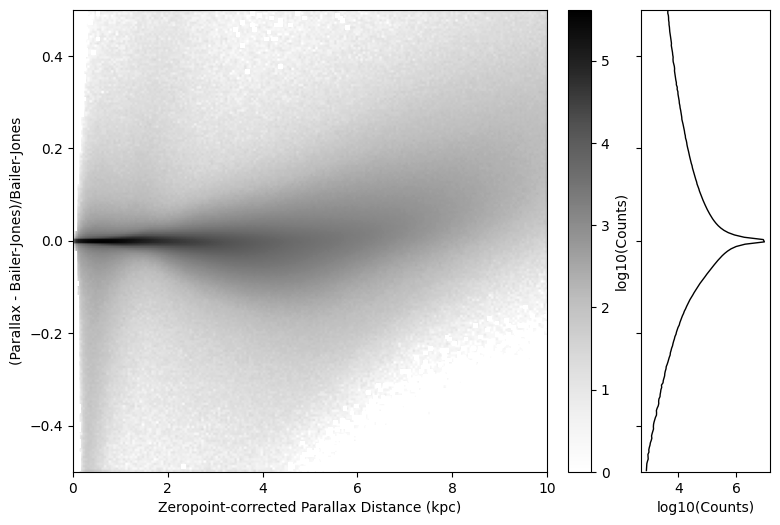

In [17]:

d1 = 1/smalldf_pd['parallax_corrected']
d2 = smalldf_pd['r_med_photogeo']/1000
print(d1.shape)

x_bounds = (0, 10)
y_bounds = (-0.5, 0.5)

y_vals = (d1 - d2) / d2

H, xe, ye = easy2dhist.hist2d_raw(d1, y_vals, bins=(200, 200), xrange=x_bounds, yrange=y_bounds)
plot_extent = [x_bounds[0], x_bounds[1], y_bounds[0], y_bounds[1]]

counts, bin_edges = np.histogram(y_vals, bins=200, range=y_bounds)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

fig = plt.figure(figsize=(9, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.15)

ax_main = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1], sharey=ax_main)

# Main 2D histogram panel
im = ax_main.imshow(
    np.log10(H.T),
    extent=plot_extent,
    origin='lower',
    aspect='auto',
    cmap=cm.Greys
)
ax_main.set_xlabel('Zeropoint-corrected Parallax Distance (kpc)')
ax_main.set_ylabel('(Parallax - Bailer-Jones)/Bailer-Jones')
fig.colorbar(im, ax=ax_main, label='log10(Counts)', fraction=0.046, pad=0.04)

# Side panel: log10(counts) plotted as a curve against bin_centers on the y-axis
log_counts = np.log10(counts, where=counts > 0, out=np.full_like(counts, np.nan, dtype=float))
ax_hist.plot(log_counts, bin_centers, color='black', lw=1)
ax_hist.set_xlabel('log10(Counts)')

plt.setp(ax_hist.get_yticklabels(), visible=False)

plt.show()

(33581727,)


/tmp/ipykernel_3008/2536751583.py:24: RuntimeWarning: divide by zero encountered in log10
  np.log10(H.T),


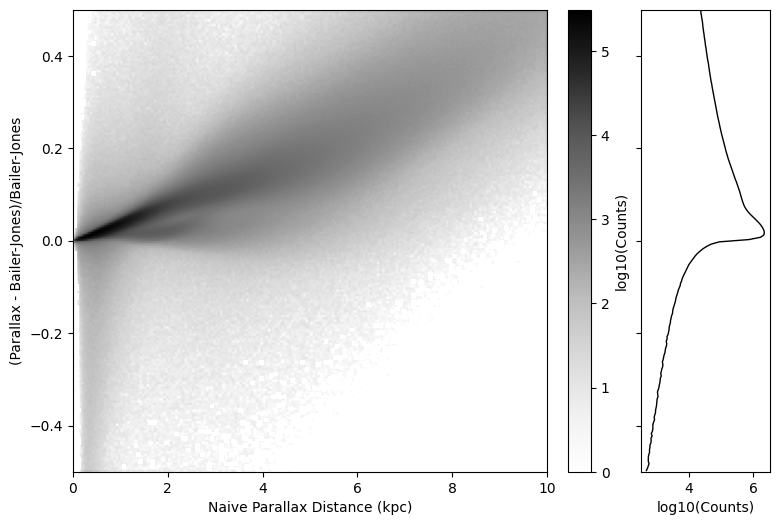

In [18]:

d1 = 1/smalldf_pd['parallax']
d2 = smalldf_pd['r_med_photogeo']/1000
print(d1.shape)

x_bounds = (0, 10)
y_bounds = (-0.5, 0.5)

y_vals = (d1 - d2) / d2

H, xe, ye = easy2dhist.hist2d_raw(d1, y_vals, bins=(200, 200), xrange=x_bounds, yrange=y_bounds)
plot_extent = [x_bounds[0], x_bounds[1], y_bounds[0], y_bounds[1]]

counts, bin_edges = np.histogram(y_vals, bins=200, range=y_bounds)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

fig = plt.figure(figsize=(9, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.15)

ax_main = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1], sharey=ax_main)

# Main 2D histogram panel
im = ax_main.imshow(
    np.log10(H.T),
    extent=plot_extent,
    origin='lower',
    aspect='auto',
    cmap=cm.Greys
)
ax_main.set_xlabel('Naive Parallax Distance (kpc)')
ax_main.set_ylabel('(Parallax - Bailer-Jones)/Bailer-Jones')
fig.colorbar(im, ax=ax_main, label='log10(Counts)', fraction=0.046, pad=0.04)

# Side panel: log10(counts) plotted as a curve against bin_centers on the y-axis
log_counts = np.log10(counts, where=counts > 0, out=np.full_like(counts, np.nan, dtype=float))
ax_hist.plot(log_counts, bin_centers, color='black', lw=1)
ax_hist.set_xlabel('log10(Counts)')

plt.setp(ax_hist.get_yticklabels(), visible=False)

plt.show()

We can also invert the problem by making parallax measurement estiamtes from the Bailer-Jones distances. In this case, we can check and see how the parallax error from Gaia compares with the distance determination.

(33581727,)


/tmp/ipykernel_3008/1440351554.py:25: RuntimeWarning: divide by zero encountered in log10
  np.log10(H.T),


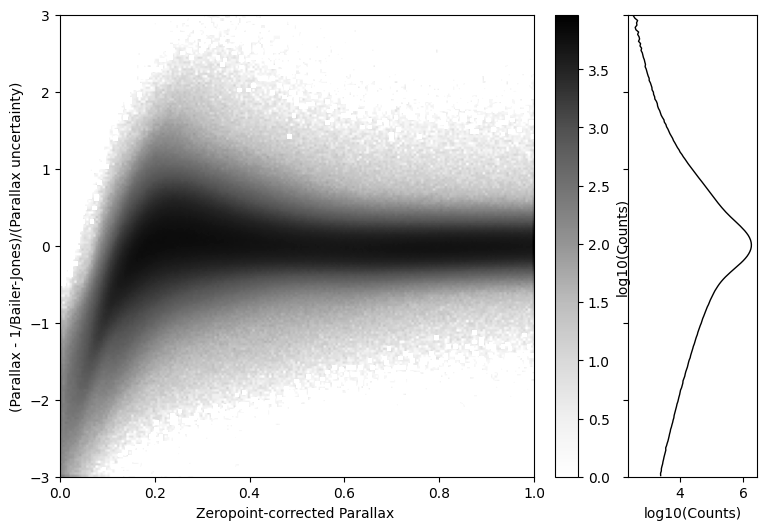

In [19]:

d1 = smalldf_pd['parallax_corrected']
d2 = 1/(smalldf_pd['r_med_photogeo']/1000)
d3 = smalldf_pd['parallax_error']
print(d1.shape)

x_bounds = (0, 1.)
y_bounds = (-3, 3)

y_vals = (d1 - d2) / d3

H, xe, ye = easy2dhist.hist2d_raw(d1, y_vals, bins=(200, 200), xrange=x_bounds, yrange=y_bounds)
plot_extent = [x_bounds[0], x_bounds[1], y_bounds[0], y_bounds[1]]

counts, bin_edges = np.histogram(y_vals, bins=200, range=y_bounds)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

fig = plt.figure(figsize=(9, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.15)

ax_main = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1], sharey=ax_main)

# Main 2D histogram panel
im = ax_main.imshow(
    np.log10(H.T),
    extent=plot_extent,
    origin='lower',
    aspect='auto',
    cmap=cm.Greys
)
ax_main.set_xlabel('Zeropoint-corrected Parallax ')
ax_main.set_ylabel('(Parallax - 1/Bailer-Jones)/(Parallax uncertainty)')
fig.colorbar(im, ax=ax_main, label='log10(Counts)', fraction=0.046, pad=0.04)

# Side panel: log10(counts) plotted as a curve against bin_centers on the y-axis
log_counts = np.log10(counts, where=counts > 0, out=np.full_like(counts, np.nan, dtype=float))
ax_hist.plot(log_counts, bin_centers, color='black', lw=1)
ax_hist.set_xlabel('log10(Counts)')

plt.setp(ax_hist.get_yticklabels(), visible=False)

plt.show()

We see that only at low parallaxes (<0.2, or distances larger than 5kpc) do we start to see a real measureable disagreement between the observed parallaxes and the estimated parallax measurements from inverting the distance.

Next, we'll try and isolate where the problematic sources are coming from.

(3801837,)


/tmp/ipykernel_3008/4005196742.py:29: RuntimeWarning: divide by zero encountered in log10
  np.log10(H.T),


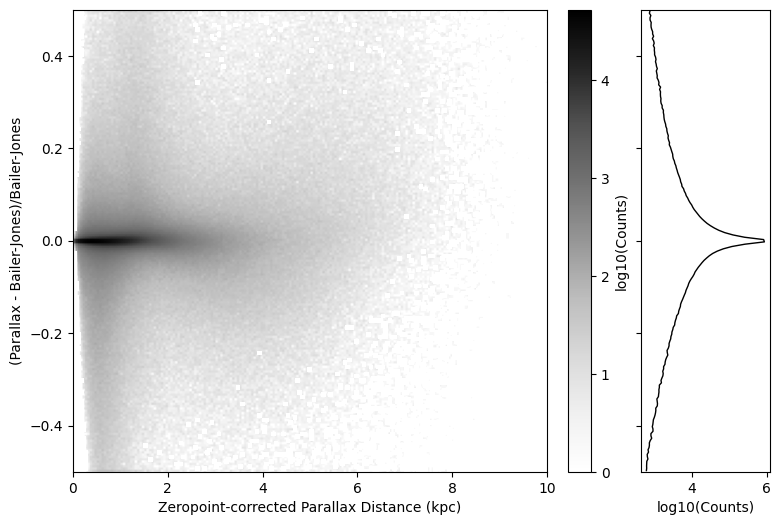

In [20]:

# high ruwe sources don't show any systematic bias
small_df_highruwe = smalldf_pd[smalldf_pd['ruwe'] > 1.4]


d1 = 1/small_df_highruwe['parallax_corrected']
d2 = small_df_highruwe['r_med_photogeo']/1000
print(d1.shape)

x_bounds = (0, 10)
y_bounds = (-0.5, 0.5)

x_vals = d2
y_vals = (d1 - d2) / d2

H, xe, ye = easy2dhist.hist2d_raw(x_vals, y_vals, bins=(200, 200), xrange=x_bounds, yrange=y_bounds)
plot_extent = [x_bounds[0], x_bounds[1], y_bounds[0], y_bounds[1]]

counts, bin_edges = np.histogram(y_vals, bins=200, range=y_bounds)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

fig = plt.figure(figsize=(9, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.15)

ax_main = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1], sharey=ax_main)

# Main 2D histogram panel
im = ax_main.imshow(
    np.log10(H.T),
    extent=plot_extent,
    origin='lower',
    aspect='auto',
    cmap=cm.Greys
)
ax_main.set_xlabel('Zeropoint-corrected Parallax Distance (kpc)')
ax_main.set_ylabel('(Parallax - Bailer-Jones)/Bailer-Jones')
fig.colorbar(im, ax=ax_main, label='log10(Counts)', fraction=0.046, pad=0.04)

# Side panel: log10(counts) plotted as a curve against bin_centers on the y-axis
log_counts = np.log10(counts, where=counts > 0, out=np.full_like(counts, np.nan, dtype=float))
ax_hist.plot(log_counts, bin_centers, color='black', lw=1)
ax_hist.set_xlabel('log10(Counts)')

plt.setp(ax_hist.get_yticklabels(), visible=False)

plt.show()

The issues aren't coming from high-ruwe sources -- those distances all more-or-less work!

(2029278,)


/tmp/ipykernel_3008/1464593157.py:28: RuntimeWarning: divide by zero encountered in log10
  np.log10(H.T),


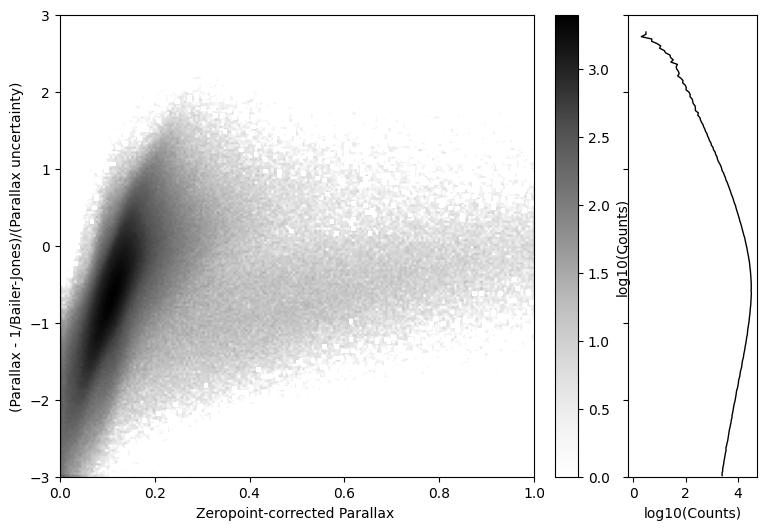

In [21]:

small_df_highruwe = smalldf_pd[ (smalldf_pd['parallax_over_error'] < 3 ) & (smalldf_pd['phot_g_mean_mag'] < 22)]

d1 = small_df_highruwe['parallax_corrected']
d2 = 1/(small_df_highruwe['r_med_photogeo']/1000)
d3 = small_df_highruwe['parallax_error']
print(d1.shape)

x_bounds = (0, 1.)
y_bounds = (-3, 3)

x_vals = d1
y_vals = (d1 - d2) / d3

H, xe, ye = easy2dhist.hist2d_raw(x_vals, y_vals, bins=(200, 200), xrange=x_bounds, yrange=y_bounds)
plot_extent = [x_bounds[0], x_bounds[1], y_bounds[0], y_bounds[1]]

counts, bin_edges = np.histogram(y_vals, bins=200, range=y_bounds)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

fig = plt.figure(figsize=(9, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.15)

ax_main = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1], sharey=ax_main)

# Main 2D histogram panel
im = ax_main.imshow(
    np.log10(H.T),
    extent=plot_extent,
    origin='lower',
    aspect='auto',
    cmap=cm.Greys
)
ax_main.set_xlabel('Zeropoint-corrected Parallax ')
ax_main.set_ylabel('(Parallax - 1/Bailer-Jones)/(Parallax uncertainty)')
fig.colorbar(im, ax=ax_main, label='log10(Counts)', fraction=0.046, pad=0.04)

# Side panel: log10(counts) plotted as a curve against bin_centers on the y-axis
log_counts = np.log10(counts, where=counts > 0, out=np.full_like(counts, np.nan, dtype=float))
ax_hist.plot(log_counts, bin_centers, color='black', lw=1)
ax_hist.set_xlabel('log10(Counts)')

plt.setp(ax_hist.get_yticklabels(), visible=False)

plt.show()

The problem is the low-signal-to-noise sources, which is to be expected! The finding confirms that a cut of 5 on the significance is safe, in the sense that using the raw distances won't help you relative to the inverted parallaxes. 